[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


7203.T
signal
0    420
1     70
Name: count, dtype: int64
3914.T
signal
0    962
1     34
Name: count, dtype: int64
7779.T
signal
0    981
1     30
Name: count, dtype: int64
2586.T
signal
0    922
1     28
Name: count, dtype: int64


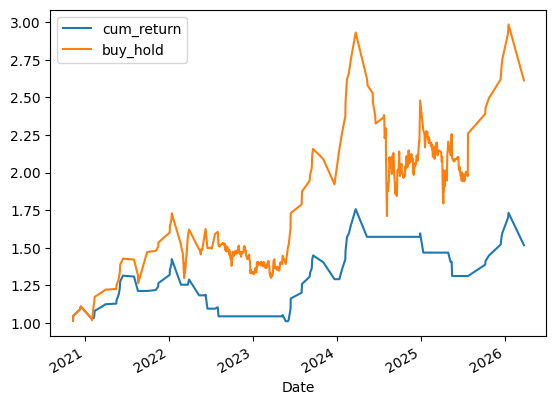

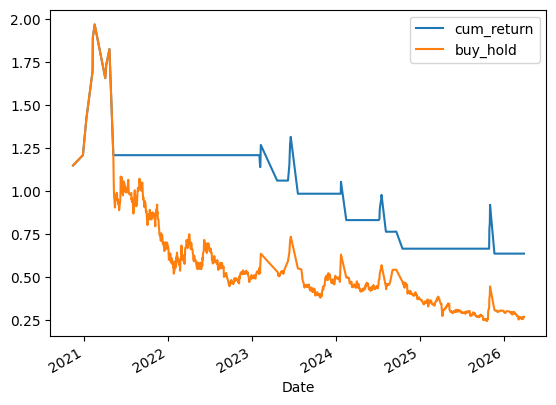

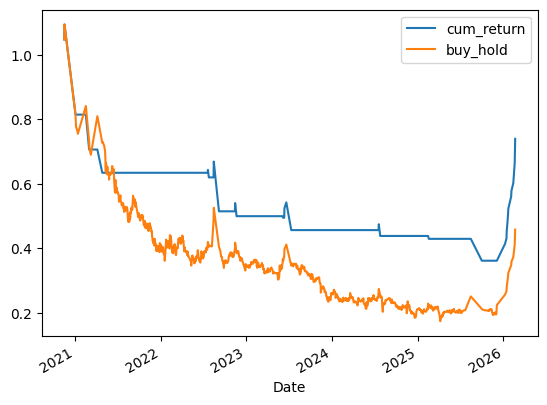

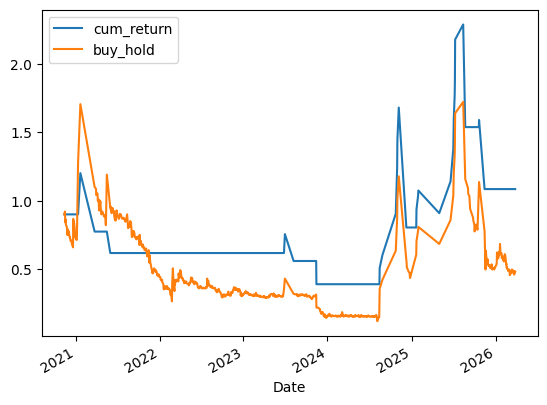

In [38]:
import yfinance as yf
import pandas as pd


#株価売買戦略
def create_signal(df):
    # 指標
    df["high_20"] = df["High"].rolling(20).max()
    df["low_30"] = df["Low"].rolling(30).min()
    df["vol_ma"] = df["Volume"].rolling(20).mean()


     # ===  トレンドフィルター追加 ===
    df["ma_25"] = df["Close"].rolling(25).mean()
    df["trend_flag"] = df["Close"] > df["ma_25"]


     # === 🔥 トレンド（長期） ===
    df["ma_200"] = df["Close"].rolling(200).mean()
    df["long_trend"] = df["Close"] > df["ma_200"]


    df["signal"] = pd.NA
    df.loc[(df["Close"] > df["high_20"].shift(1))&((df["Volume"] > df["vol_ma"]))&(df["trend_flag"])& (df["long_trend"]), "signal"] = 1


     # === 🔥 entry_price作成 ===
    df["entry_price"] = df["Close"].where(df["signal"] == 1)
    df["entry_price"] = df["entry_price"].ffill()


    df.loc[df["Close"] < df["low_30"].shift(1), "signal"] = 0

    # === 🔥 長期トレンド崩れたら即撤退 ===
    df.loc[df["Close"] < df["ma_200"], "signal"] = 0

    #改善①：短期損切り
    #df.loc[df["Close"] < df["entry_price"] * 0.95, "signal"] = 0

    # 改善②：利確（超重要）
    #df.loc[df["Close"] > df["entry_price"]* 1.1, "signal"] = 0

    df["position"] = df["signal"].ffill().fillna(0).shift(1)
    #ffillはnaである行があったらn-1行目の値で埋める
    df = df.dropna()
    return df


results={}
tickers = ["7203.T", "3914.T", "7779.T", "2586.T"]
for ticker in tickers:
    df = yf.download(ticker, start="2020-01-01", interval="1D")
    df.columns = df.columns.get_level_values(0)
    df.columns.name = None
    df = create_signal(df)
    results[ticker] = df

for ticker, df in results.items():
    print(ticker)
    print(df["signal"].value_counts())

    df["return"] = df["Close"].pct_change()
    # 戦略リターン
    df["strategy_return"] = df["position"] * df["return"]
    # 累積
    df["cum_return"] = (1 + df["strategy_return"]).cumprod()
    # 比較
    df["buy_hold"] = (1 + df["return"]).cumprod()

    df[["cum_return", "buy_hold"]].plot()


In [34]:
import yfinance as yf
import pandas as pd

tickers = ["7203.T", "6758.T", "9984.T", "2586.T"]


def create_signal(df):
    df["high_20"] = df["High"].rolling(20).max()
    df["low_20"] = df["Low"].rolling(20).min()
    df["vol_ma"] = df["Volume"].rolling(20).mean()

    df["signal"] = 0
    df.loc[df["Close"] > df["high_20"].shift(1), "signal"] = 1
    df.loc[df["Close"] < df["low_20"].shift(1), "signal"] = -1

    return df


results = {}

for ticker in tickers:
    df = yf.download(ticker, start="2018-01-01")
    df.columns = df.columns.get_level_values(0)
    
    df = create_signal(df)
    
    results[ticker] = df


for ticker, df in results.items():
    print(ticker)
    print(df["signal"].value_counts())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

7203.T
signal
 0    1785
 1     135
-1     103
Name: count, dtype: int64
6758.T
signal
 0    1776
 1     150
-1      97
Name: count, dtype: int64
9984.T
signal
 0    1734
 1     162
-1     127
Name: count, dtype: int64
2586.T
signal
 0    1810
-1     146
 1      67
Name: count, dtype: int64
